# American Dialect Classification with Wav2Vec and Linear Classifiers

This notebook explores multiclass classification of speech samples by dialect. In this approach, I extract Wav2Vec embeddings on the whole utterance and train linear classifiers, specifically logistic regression and support vector machines.

I used the TIMIT dataset, summarized below:
| Region # | Region name              | # Speakers |
|----------|--------------------------|------------|
| DR1      | New England              | 49         |
| DR2      | Northern                 | 102        |
| DR3      | North Midland            | 102        |
| DR4      | South Midland            | 100        |
| DR5      | Southern                 | 98         |
| DR6      | New York City            | 46         |
| DR7      | Western                  | 100        |

In [2]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model, logging
import torch
import torchaudio
import glob
import numpy as np

DATA_PATH = "../data/raw/TIMIT/data"
N_REGIONS = 7
utterances = ["SA1", "SA2"]

logging.set_verbosity_error()

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", output_hidden_states=True)
model.eval()  # inference mode

None

Loading weights: 100%|████████████████████████████████████| 211/211 [00:00<00:00, 20477.54it/s]


In [3]:
def extract_embedding(wav):

    # load wav
    y, sr = torchaudio.load(wav)

    # TIMIT sr should be 16kHz, but resample if not
    if sr != 16000: 
        y = torchaudio.transforms.Resample(sr, 16000)(y)
    y = y.squeeze(0)  # remove channel dim if mono, model expects 1D waveform

    # get wav2vec embedding
    inputs = feature_extractor(y, sampling_rate=16000, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    hidden_states = outputs.hidden_states
    
    # average middle 4 layers
    layers = hidden_states[6:10]
    stacked = torch.stack(layers)
    layer_avg = stacked.mean(dim=0)
    
    # mean + std pooling
    mean = layer_avg.mean(dim=1) # (1, 768)
    std = layer_avg.std(dim=1)  # (1, 768)
    
    embedding = torch.cat([mean, std], dim=1)  # (1, 1536)

    return embedding

In [4]:
def get_data(utterances=None):
    data = {"train": {}, "test": {}}
    
    for split in ["TRAIN", "TEST"]:
        s = split.lower()
        paths = []
        
        for d in range(1, N_REGIONS + 1):
            if utterances is not None:
                for utt in utterances:
                    paths += glob.glob(f'{DATA_PATH}/{split}/DR{d}/*/{utt}.WAV')
            else: # use full dataset
                paths += glob.glob(f'{DATA_PATH}/{split}/DR{d}/*/*.WAV')

        for wav in paths:

            path_split = wav.split("/")
            dialect = int(path_split[6][2]) - 1
            speaker = path_split[7]
            utt = path_split[8].replace(".WAV", "")

            embedding = extract_embedding(wav) # (1, 1536)
    
            if speaker not in data[s]:
                data[s][speaker] = {"dialect": dialect, "utterances": {}}

            if embedding is not None:
                data[s][speaker]["utterances"][utt] = embedding

    return data

data = get_data(utterances)

In [5]:
print(f'{data["train"]["MRBC0"]["utterances"].keys()}\n{data["train"]["MRBC0"]["utterances"]["SA1"].shape}')

dict_keys(['SA1', 'SA2'])
torch.Size([1, 1536])


In [8]:
def stack_embeddings(data, split):
    X = []
    y = []

    for speaker in data[split].values():
        
        utterances = list(speaker["utterances"].values())
        X += utterances
        y += [speaker["dialect"]] * len(utterances)

    X = np.vstack(X)
    y = np.array(y)

    return X, y

X_train, y_train = stack_embeddings(data, "train")
X_test, y_test = stack_embeddings(data, "test")

# shapes should be (n_speakers * 2, 1536) (n_speakers * 2,)
print(f'{X_train.shape} | {y_train.shape}')

(880, 1536) | (880,)


### Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000, class_weight="balanced")

# parameter search
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(lr, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test_scaled)

print(f'Best parameters: {grid.best_params_}\n')
print(classification_report(y_test, y_pred))

Best parameters: {'C': 100}

              precision    recall  f1-score   support

           0       0.38      0.45      0.42        22
           1       0.60      0.58      0.59        52
           2       0.23      0.21      0.22        52
           3       0.45      0.42      0.44        64
           4       0.35      0.30      0.32        56
           5       0.23      0.36      0.28        22
           6       0.38      0.39      0.39        46

    accuracy                           0.39       314
   macro avg       0.38      0.39      0.38       314
weighted avg       0.39      0.39      0.39       314



39% accuracy shows that the model is better than random guessing (approx 1/7 = ~14%) and is learning something, but is not performing well enough to be reliable.

Class 1 (DR2 - Northern) performs the best, while class 2 (DR3 - North Midland) and class 5 (DR6 - New York City) seem to be especially difficult for the model. This somewhat follows the results I got from the MFCC pairwise ELM approach I tried previously – DR2 is strong while DR6 is weak. However, logistic regression performs relatively well with class 3 (DR4 - South Midland), which was the ELM’s weakest class.

All things considered, wav2vec + logistic regression performed better than my MFCC + pairwise ELMs attempt (39% vs. 29% accuracy).

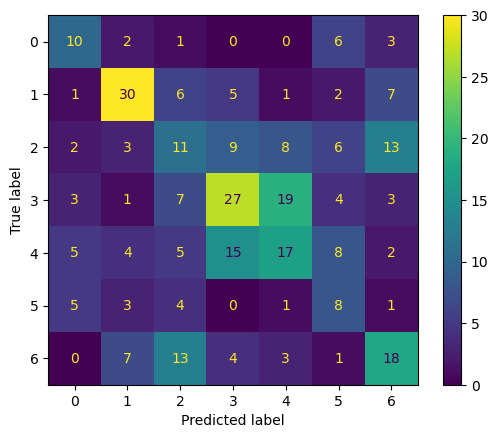

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Here are some interesting patterns I found glancing at this:
- Class 0 (DR1 - New England) is sometimes confused with class 5 (DR6 - New York City). This tracks since these dialects share a lot of salient features, such as non-rhoticity and (sometimes) no cot-caught merger.
- Class 1 (DR2 - Northern) is sometimes confused with classes 2 (DR3 - North Midland), 3 (DR4 - South Midland), and 6 (DR7 - Western). These dialects are all rhotic and have the cot-caught merger (or at least in transition.)
- In general, classes 2 (DR3 - North Midland), 3 (DR4 - South Midland), 4 (DR 5 - Southern), and 6 (DR 7 - Western) are conflated with one another.

So overall, the model confuses similar dialects with one another, which is to be expected. Interestingly, however, DR3 - North Midland, DR4 - South Midland, DR5 - Southern, and DR7 - Western seem to behave like a cluster; if a sample resembles one dialect in this group, the model often predicts one of the other dialects in the same group.


### SVM

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

              precision    recall  f1-score   support

           0       0.43      0.14      0.21        22
           1       0.40      0.60      0.48        52
           2       0.24      0.31      0.27        52
           3       0.47      0.36      0.41        64
           4       0.44      0.39      0.42        56
           5       0.50      0.18      0.27        22
           6       0.27      0.33      0.29        46

    accuracy                           0.36       314
   macro avg       0.39      0.33      0.33       314
weighted avg       0.38      0.36      0.36       314



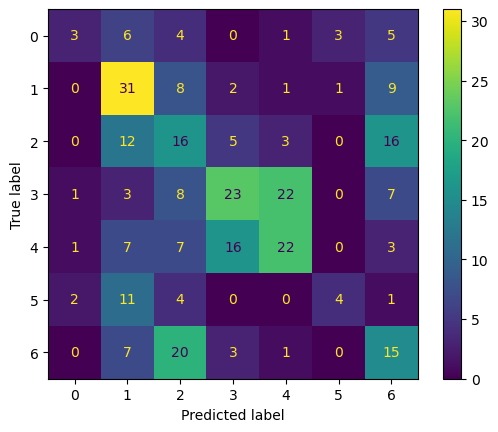

In [11]:
from sklearn.svm import SVC

svm = SVC(class_weight="balanced")

# parameter search
param_grid = {"kernel": ["linear", "rbf"], "C": [0.01, 0.1, 1, 10, 100], "gamma": ["scale", "auto"]}
grid = GridSearchCV(svm, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

print(f'Best parameters: {grid.best_params_}\n')
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Logistic regression slightly outperformed the SVM (39% vs. 36% accuracy), though the difference is small and not likely to be statistically significant given the dataset size. Additionally, the confusion matrix reflects the same sort of pattern highlighted above.

### Learning Curve for LR

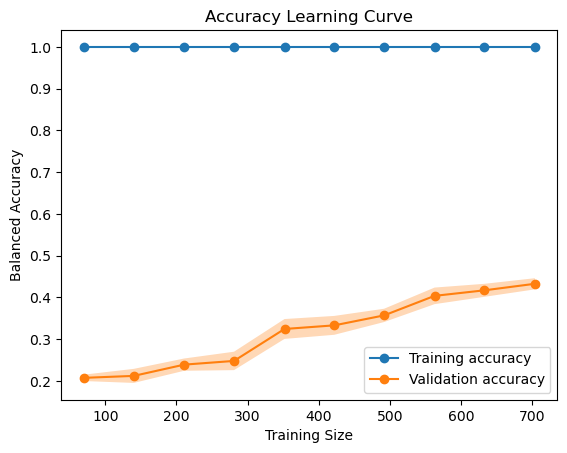

In [53]:
from sklearn.model_selection import learning_curve, StratifiedKFold

lr = LogisticRegression(max_iter=2000, class_weight="balanced", C=100)

# account for class imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=64)

train_sizes, train_scores, val_scores = learning_curve(lr,
                                                       X_train_scaled,
                                                       y_train,
                                                       cv=cv,
                                                       scoring="balanced_accuracy",
                                                       train_sizes=np.linspace(0.1, 1.0, 10),
                                                       n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)

plt.plot(train_sizes, val_mean, marker="o", label="Validation accuracy")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.3)

plt.xlabel("Training Size")
plt.ylabel("Balanced Accuracy")
plt.title("Accuracy Learning Curve")
plt.legend()

plt.show()

The model is overfitting to the training data, however, generalization steadily improves with the introduction of more data. ~0.4 validation accuracy is not ideal, but again, still better than random chance. All things considered, the embeddings are useful and logistic regression has enough capacity for the task at hand, but the overall bottleneck seems to be dataset size.


### References

1. Garofolo, John S., et al. TIMIT Acoustic-Phonetic Continuous Speech Corpus LDC93S1. Web 
Download. Philadelphia: Linguistic Data Consortium, 1993.